# AI tools usage in software development survey analysis
by Karol

## Problem Statement
This analysis aims to understand how AI tools are used in software development, based on respondent responses in StackOverflow Developer Survey 2025. Analysis focuses on users of AI tools in software development, their age, role, industry, and trust of generated AI output. The goal is to provide insights into the adoption and impact of AI tools in the software development industry. Analysis tries to answer for following questions:
1. How much AI tools were actively used in software development by different age groups?
2. How much AI tools were actively used in software development by different roles?
3. How much AI tools were actively used in software development by different industries?
4. How did respondents rate the accuracy of results generated by AI tools, depending on the extent of their use?

## Conclusions

Performed analysis allowed to conclude following observations:

* There is observed trend between AI tools usage and age of respondent: the younger the respondent the highest AI tools usage.
* Export developing AI-solutions, Web Developers, Senior Executives and Software Architectures are roles in Software Development that uses AI tools in their work the most actively. AI tools are used the least by Operations and by Game Developers.
* Respondents working in Fintech and Software Development are using AI tool the most. At least 70% of respondents from these industries are using AI tools in their day-to-day work. AI tools are the least popular in Higher Education and Government with usage on levels 57% and 53% accordingly.
* Extend of AI tools usage seems to be explained by level of trust of AI generated output. People that uses autonomous agents seems to show the highest trust. These responds that doesn't use AI tools actively shows distrust.

## Dataset understanding and cleaning

In this section, I'm going to understand available dataset and clean it for further analysis. The dataset contains survey responses from software developers regarding their work (including AI usage).

Let's first import required libraries:

In [1]:
import numpy as np
import pandas as pd

Now, let's load the survey data from CSV file:

In [2]:
raw_df = pd.read_csv('data/raw_data.csv')
raw_df.head(5)

,ResponseId,MainBranch,Age,EdLevel,Employment,YearsCode,DevType,OrgSize,Industry,JobSat,Country,SOVisitFreq,AIThreat,AIModelsChoice,AISelect,AIAcc,AIComplex,AIAgents
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,14.0,"Developer, mobile",20 to 99 employees,Fintech,10.0,Ukraine,A few times per week,I'm not sure,Yes,"Yes, I use AI tools monthly or infrequently",Neither trust nor distrust,Bad at handling complex tasks,"Yes, I use AI agents at work monthly or infreq..."
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,10.0,"Developer, back-end",500 to 999 employees,Retail and Consumer Services,9.0,Netherlands,Multiple times per day,I'm not sure,Yes,"Yes, I use AI tools weekly",Neither trust nor distrust,Bad at handling complex tasks,"No, and I don't plan to"
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",12.0,"Developer, front-end",NaN,Software Development,8.0,Ukraine,A few times per week,No,Yes,"Yes, I use AI tools daily",Somewhat trust,Neither good or bad at handling complex tasks,"Yes, I use AI agents at work weekly"
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,5.0,"Developer, back-end","10,000 or more employees",Retail and Consumer Services,6.0,Ukraine,A few times per month or weekly,No,No,"Yes, I use AI tools weekly",Somewhat trust,Bad at handling complex tasks,"Yes, I use AI agents at work monthly or infreq..."
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...",22.0,Engineering manager,NaN,Software Development,7.0,Ukraine,A few times per month or weekly,No,Yes,"Yes, I use AI tools weekly",Neither trust nor distrust,"Good, but not great at handling complex tasks","No, and I don't plan to"


This datasets contains **49 191** survey responses from software developers. There are responses for 18 questions (some of columns were removed from original dataset)

| Column Name    | Data Type   | Description                                                              |
|----------------|-------------|--------------------------------------------------------------------------|
| ResponseId     | numeric     | Unique identifier for each survey response                               |
| MainBranch     | categorical | Profile of the respondent                                                |
| Age            | categorical | Age group of the respondent                                              |
| EdLevel        | categorical | Education level of the respondent                                        |
| Employment     | categorical | Employment status of the respondent                                      |
| YearsCode      | numeric     | Years of the respondent coding experience                                |
| DevType        | categorical | Type of developer the respondent is                                      |
| OrgSize        | categorical | Size of respondent organization                                          |
| Industry       | categorical | Industry respondent works for                                            |
| JobSat         | numeric     | Respondent job satisfaction                                              |
| Country        | categorical | Country of the respondent                                                |
| SOVisitFreq    | categorical | StackOverflow visits frequency                                           |
| AIThreat       | categorical | Is AI threat to respondent job?                                          |
| AIModelsChoice | categorical | Does respondent use any LLM at work?                                     |
| AISelect       | categorical | Does respondent use any AI tools in development process?                 |
| AIAcc          | categorical | How much respondent trust trust the accuracy of the output from AI tools |
| AIComplex      | categorical | How well AI tools handle complex tasks?                                  |
| AIAgents       | categorical | Does respondent uses autonomous agents in development work?              |



### Missing values cleaning
Let's deal with missing values in the dataset. First let's replace responses that indicates no answer with nan values:

In [3]:
# Let's use nan to represent missing values in the dataset
raw_df['Age'] = raw_df['Age'].replace({'Prefer not to say': np.nan})
raw_df['EdLevel'] = raw_df['EdLevel'].replace({'Other (please specify):': np.nan})
raw_df['Employment'] = raw_df['Employment'].replace({'I prefer not to say': np.nan})
raw_df['DevType'] = raw_df['DevType'].replace({'Other (please specify):': np.nan})
raw_df['OrgSize'] = raw_df['OrgSize'].replace({'I don’t know': np.nan})
raw_df['Industry'] = raw_df['Industry'].replace({'Other:': np.nan})

Now, let's see how many missing values we have in each column:

In [4]:
raw_df.isna().sum().sort_values(ascending=False)

JobSat            22521
AIModelsChoice    18952
Industry          18216
AIAgents          17272
SOVisitFreq       16481
OrgSize           15945
AIComplex         15908
AIAcc             15894
AISelect          15471
Country           13754
AIThreat          13113
DevType            7336
YearsCode          6149
EdLevel            1743
Employment         1370
Age                 378
MainBranch            0
ResponseId            0
dtype: int64

In some cases we are missing a lot of values, for example in `JobSat` and `AIModelsChoice`.

Since out analysis aims to answer so specific questions, only subset of these columns have values for us. Let's keep only needed columns:

In [5]:
raw_df = raw_df[['ResponseId', 'Age', 'DevType', 'Industry', 'AISelect', 'AIAgents', 'AIAcc']]
raw_df.isna().sum().sort_values(ascending=False)

Industry      18216
AIAgents      17272
AIAcc         15894
AISelect      15471
DevType        7336
Age             378
ResponseId        0
dtype: int64

This dataset contains **49 191** records. We are still missing quite lot of values (especially for `Industry` and `AIAgents` columns), but it's still less than 37% of total records. Let's keep only records that have values for `Age`, `DevType`, `Industry`, `AISelect`, `AIAgents` and `AIAcc`. That subset should be sufficient for us to perform analysis.

In [6]:
raw_df = raw_df[raw_df.isna().sum(axis=1) == 0]
raw_df.isna().sum().sort_values(ascending=False)

ResponseId    0
Age           0
DevType       0
Industry      0
AISelect      0
AIAgents      0
AIAcc         0
dtype: int64

### Values conversion
Let's convert columns to categorical data types. Let's write function so it can be easily reused later:

In [7]:
def convert_to_categorical(source_df):
    """
    Convert columns to categorical data types.
    :param source_df: dataframe to convert
    :return: df: dataframe with converted columns
    """
    df = source_df.copy()

    df['Age'] = pd.Categorical(
        df["Age"],
        categories=['18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older'],
        ordered=True
    )

    df['AISelect'] = pd.Categorical(
        df["AISelect"],
        categories=[
            'Yes, I use AI tools daily',
            'Yes, I use AI tools weekly',
            'Yes, I use AI tools monthly or infrequently',
            'No, but I plan to soon',
            "No, and I don't plan to"
        ],
        ordered=True
    )

    df['AIAgents'] = pd.Categorical(
        df["AIAgents"],
        categories=[
            'Yes, I use AI agents at work daily',
            'Yes, I use AI agents at work weekly',
            'Yes, I use AI agents at work monthly or infrequently',
            'No, I use AI exclusively in copilot/autocomplete mode',
            'No, but I plan to',
            "No, and I don't plan to"
        ],
        ordered=True
    )

    df['AIAcc'] = pd.Categorical(
        df["AIAcc"],
        categories=[
            'Highly trust',
            'Somewhat trust',
            'Neither trust nor distrust',
            'Somewhat distrust',
            'Highly distrust',
        ],
        ordered=True
    )

    df['DevType'] = pd.Categorical(
        df['DevType'],
        categories=df['DevType'].unique().tolist(),
        ordered=False
    )

    df['Industry'] = pd.Categorical(
        df['Industry'],
        categories=df['Industry'].unique().tolist(),
        ordered=False
    )

    return df

Let's use this function and save cleaned dataset to CSV file for further analysis:

In [8]:
convert_to_categorical(raw_df).to_csv('data/cleaned_data.csv', index=False)

## Business questions

Let's try to answer for questions. Start with importing required libraries and loading cleaned dataset:

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/cleaned_data.csv')
df = convert_to_categorical(df)

Let's define mapping for `AISelect` column:

In [10]:
ai_select_mapping = {
    'Yes, I use AI tools daily': 'Yes',
    'Yes, I use AI tools weekly': 'Yes',
    'Yes, I use AI tools monthly or infrequently': 'No', # once a month it's not active usage
    'No, and I don\'t plan to': 'No',
    'No, but I plan to soon': 'No'
}

###  Question 1: How much AI tools were actively used in software development by different age groups?
Let's first analyse active AI tools usage in software development in 2025 per age group. In order to answer for that question we can use `AISelect` and `Age` columns:


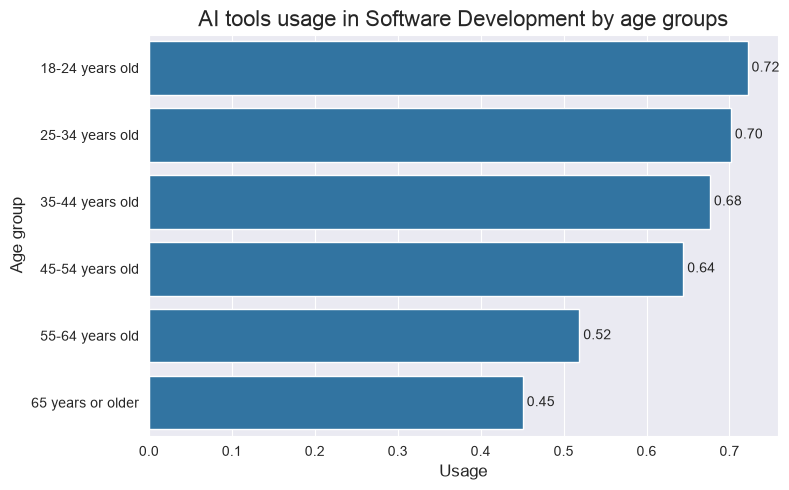

In [11]:
question_1_df = df[['Age', 'AISelect']].copy()

# Build `AIUsage` column to know whether respondent active applies AI tools in its work
question_1_df['AIUsage'] = question_1_df['AISelect'].map(ai_select_mapping)

# Group by Age groups
answer_question_1_df = question_1_df.groupby('Age')['AIUsage'] \
    .value_counts(normalize=True)\
    .unstack() \
    .reset_index()

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=answer_question_1_df,
    x='Yes',
    y='Age',
)

plt.title("AI tools usage in Software Development by age groups", fontsize=16)
plt.xlabel("Usage", fontsize=12)
plt.ylabel("Age group", fontsize=12)
ax.bar_label(ax.containers[0], fmt=" %.2f")

plt.tight_layout()
plt.show()


Above charts shows that in age groups between 18-54 years old (4 age groups) there was AI tools usage above 60% in each age group. The highest AI usage was in age group 18-24 years old (72% of respondents in that age group). In group 55-64 years old, AI tools are used by 52% of respondents in this group. AI usage in last group (65 years or older) has the lowest AI tools usage (45% of respondents from that group).

There is observed trend between AI tools usage and age of respondent: the younger the respondent the highest AI tools usage.

## Question 2: How much AI tools were actively used in software development by different roles?
Now, let's analyze how much AI tools were actively used based on respondent role:

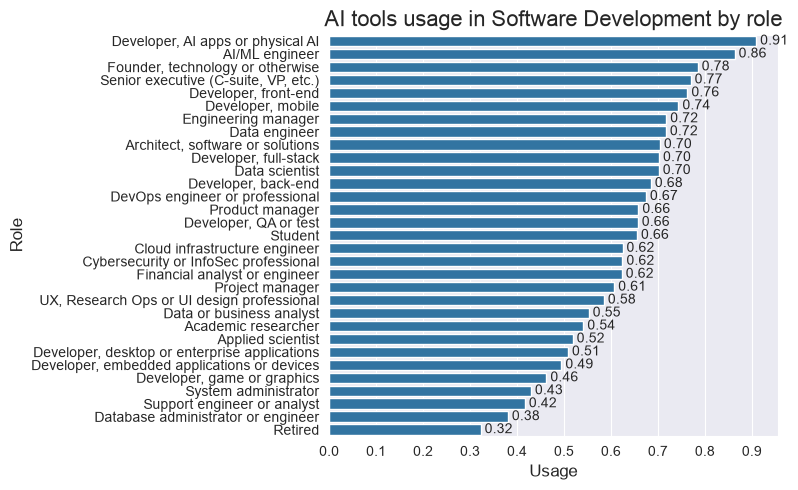

In [12]:
question_2_df = df[['DevType', 'AISelect']].copy()
question_2_df['AIUsage'] = question_1_df['AISelect'].map(ai_select_mapping)

answer_question_2_df = question_2_df.groupby('DevType')['AIUsage'] \
    .value_counts(normalize=True)\
    .unstack() \
    .reset_index()

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=answer_question_2_df,
    x='Yes',
    y='DevType',
    order=answer_question_2_df.sort_values('Yes', ascending=False)['DevType']
)

plt.title("AI tools usage in Software Development by role", fontsize=16)
plt.xlabel("Usage", fontsize=12)
plt.ylabel("Role", fontsize=12)
plt.xticks(np.arange(0, 1, 0.1))
ax.bar_label(ax.containers[0], fmt=" %.2f")

plt.tight_layout()
plt.show()


We can observe that AI tools usage between different roles is quite diverse:
* At the top, we have AI-related position (Developer AI, AI/ML Engineer). In these groups AI tools usage is between 86 and 91%.
* Next group is Founders and Senior Executives. AI tools usage within these groups is above 77%.
* Similar level (76%) of AI tools usage is found for Mobile and Front-end Developers.
* 72% AI tools usage is also observed among Engineering managers. The same result is observed for Data Engineers.
* Within the next group are Software Architects, Full-Stack Developers, Data Scientists , Back-end Developers and DevOps Engineers with result 67-70%.
* 66% is result of Product Managers, QA Engineers and Students
* AI Tools Usage for Cloud Infrastructure Engineers, Cybersecurity Specialist and Financial analyst is 62%.
* AI Tools Usage within Project Managers in 61%.
* Next, we have UX experts. AI tools usage within that group is 58%.
* 54-55% is AI tools usage for Business Analyst and Academic researchers.
* 52% is AI tools usage of Applied scientist.
* 51% of Desktop Application Developers were using AI Tools in their work.
* 49% is AI tools usage of Embedded Application Developers
* Next we gave Game-Developers with result 46% AI Tools usage.
* System Administrators and Support engineers AI tools usage is 42-43%.
* 38% is AI tools usage within Database Administrators
* At the end we have retired group with AI tools usage 32%.

Export developing AI-solutions, Web Developers, Senior Executives and Software Architectures are roles in Software Development that uses AI tools in their work the most actively. AI tools are used the least by Operations and by Game Developers.

## Question 3: How much AI is actively used in software development per industry?
Let us now examine the application of AI tools, broken down by industries:

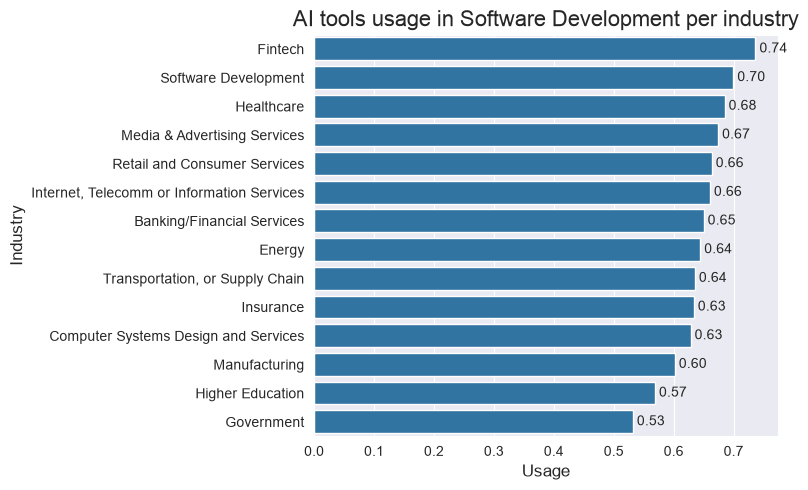

In [13]:
question_3_df = df[['Industry', 'AISelect']].copy()
question_3_df['AIUsage'] = question_3_df['AISelect'].map(ai_select_mapping)

answer_question_3_df = question_3_df.groupby('Industry')['AIUsage'] \
    .value_counts(normalize=True)\
    .unstack() \
    .reset_index() \
    .sort_values('Yes', ascending=False)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=answer_question_3_df,
    x='Yes',
    y='Industry',
    order=answer_question_3_df.sort_values('Yes', ascending=False)['Industry']
)

plt.title("AI tools usage in Software Development per industry", fontsize=16)
plt.xlabel("Usage", fontsize=12)
plt.ylabel("Industry", fontsize=12)
ax.bar_label(ax.containers[0], fmt=" %.2f")

plt.tight_layout()
plt.show()


Above chart shows following facts:
* Fintech is industry in which AI tools usage is the most with result 74% of members of that group.
* Next we have Software Development with result 70%.
* 68% of respondents working Healthcare are using AI tools.
* 67% of respondents from Media & Advertising Services are using AI tools in their software development work.
* Respondents from next group (Retail and Consumer Services, and Telecommunication Services) uses AI tool on level 66%.
* Financial Services has result 65%.
* 64% of respondents from Energy and Transportation are using AI in their work.
* Insurance and Computer System Design in next industry with result 63%.
* In Manufacturing, 60% of respondents uses actively AI tools.
* The least AI tools usage is in Higher Education and Government with results 57% and 53% accordingly.

Respondents working in Fintech and Software Development are using AI tool the most. At least 70% of respondents from these industries are using AI tools in their day-to-day work. AI tools are the least popular in Higher Education and Government with usage on levels 57% and 53% accordingly.

## Question 4: How did respondents rate the accuracy of results generated by AI tools, depending on the extent of their use?
At the end, we will try to find out how much respondents trust AI generated output. Response will be broken down into expend of AI usage by respondent:

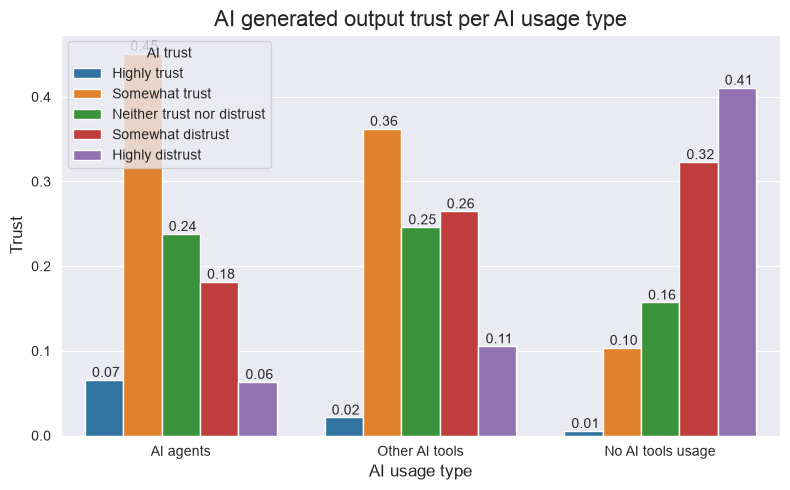

In [14]:
question_4_df = df[['AISelect', 'AIAgents', 'AIAcc']].copy()

ai_agents_mapping = {
    'Yes, I use AI agents at work daily': 'Yes',
    'Yes, I use AI agents at work weekly': 'Yes',
    'Yes, I use AI agents at work monthly or infrequently': 'No', # once a month it's not active usage
    'No, I use AI exclusively in copilot/autocomplete mode': 'No',
    'No, and I don\'t plan to': 'No',
    'No, but I plan to': 'No'
}

question_4_df['AIUsage'] = question_4_df['AISelect'].map(ai_select_mapping)
question_4_df['AIAgentsUsage'] = question_4_df['AIAgents'].map(ai_agents_mapping)

def ai_usage_type_mapping(row):
    if row['AIAgentsUsage'] == 'Yes':
        return 'AI agents'
    elif row['AIUsage'] == 'Yes':
        return 'Other AI tools'
    else:
        return 'No AI tools usage'

question_4_df['AIUsageType'] = question_4_df.apply(ai_usage_type_mapping, axis=1)
question_4_df['AIUsageType'] = pd.Categorical(
        question_4_df["AIUsageType"],
        categories=[
            'AI agents',
            'Other AI tools',
            'No AI tools usage',
        ],
        ordered=True
)

answer_question_4_df = question_4_df.groupby('AIUsageType')['AIAcc'] \
    .value_counts(normalize=True) \
    .unstack() \
    .reset_index() \
    .melt(
        id_vars="AIUsageType",
        var_name="AI trust",
        value_name="AI trust value"
    )

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=answer_question_4_df,
    x='AIUsageType',
    y='AI trust value',
    hue='AI trust',
)

plt.title("AI generated output trust per AI usage type", fontsize=16)
plt.xlabel("AI usage type", fontsize=12)
plt.ylabel("Trust", fontsize=12)
ax.bar_label(ax.containers[0], fmt=" %.2f")
ax.bar_label(ax.containers[1], fmt=" %.2f")
ax.bar_label(ax.containers[2], fmt=" %.2f")
ax.bar_label(ax.containers[3], fmt=" %.2f")
ax.bar_label(ax.containers[4], fmt=" %.2f")

plt.tight_layout()
plt.show()

We can observe correlation between AI-generated output trust and extend of AI usage:
* Group that usages AI Agents (Autonomous system with limited human interaction) that trust into AI-generated output is the highest. 7% of respondents in that group highly trust AI-generated output, while 45% of them somewhat trust that output. On the other hand, this group characterise with the lowest distrust: 18% of them somewhat distrust AI-generated output, while only 6% shows highly distrust.
* Next group represents group of people that uses AI tools with more control (AI-assistants, auto-complete, etc.). We can observe lower trust: 2% of members of that group highly trust AI generated output, while 36% of them describes their trust as "Somewhat trust". We can observe higher distrust too: 26% of respondents somewhat distrust and 11% of them highly distrust AI-generated output.
* Last group doesn't use AI actively. It can be explained by their trust level. Only 1% of respondents highly trust AI generated output, while 10% of them describe the trust as "Somewhat". On the other hand we can see high level of distruct: 32% of respondents somewhat distruct and 41% of them highly distrust AI generated output.

Extend of AI tools usage seems to be explained by level of trust of AI generated output. People that uses autonomous agents seems to show the highest trust. These responds that doesn't use AI tools actively shows distrust.